# 🏆 LG Aimers 해커톤: 제구 성공 확률 예측 (Pitch Control Success Prediction)

### 🎯 대회의 궁극적인 목적
본 대회의 핵심 목표는 **"투구가 투수의 손을 떠나기 '직전'의 상황 정보만을 바탕으로, 해당 투구가 원하는 제구 범위에 들어갈 확률(Probability)을 예측하는 AI 모델을 개발"**하는 것입니다.

* **예측 대상 (Target)**: `control_success` (1: 제구 성공, 0: 제구 실패)
* **제약 조건**: 공이 손을 떠난 '이후'에 발생한 데이터(예: 이번 공의 실시간 구속, 타격 결과 등)는 절대 예측 모델의 입력으로 사용할 수 없음. 오로지 과거 누적 기록(`asof_` 및 트랙맨)과 투구 직전의 경기 상황(이닝, 볼카운트 등)만 사용해야 함.

---

### 📝 분석가(나)가 수행해야 할 핵심 Task
1. **데이터 탐색 및 필수 전처리 (EDA & Preprocessing) [✅ 완료]**
   - 데이터 무결성 검증: 야구 규칙에 위배되는 비정상 데이터 확인 (오류 0건 확인)
   - 극단값(Outliers) 확인: 점수 차이 등 야구 특수 상황 파악 및 원본 보존 결정
   - 범주형 변수의 Label Encoding 및 단순 식별자(ID) 변수 제거

2. **파생 변수 생성 (Feature Engineering)**
   - 상황적 압박감 수치화: 투수 불리 카운트, 득점권 및 클러치 상황 지표 생성 **[✅ 완료]**
   - **[🔥 진행 예정]** 외부 데이터(Trackman) 병합: `trackman_history.csv`를 분석하여 투수별 고유 구위 능력치(평균 구속, 회전수 등)를 프로필화하여 메인 데이터에 병합

3. **머신러닝 모델링 (Modeling & Evaluation) [⏳ 대기]**
   - 트리기반 앙상블 모델(LightGBM, XGBoost 등) 구축
   - 트리 모델의 자체 분기 알고리즘을 활용한 신인 투수 결측치(Cold-start) 대처
   - 생성한 피처 중요도(Feature Importance) 분석 및 최종 확률(0.0~1.0) 도출

#**EDA : 데이터 분석 및 파악**

*   데이터 주요 변수을 알아보고 결측치와 이상치, 이상값 확인.
*   파악된 각각의 데이터를 어떻게 처리할 지 구상.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 구글 코랩 드라이브 마운트
# from google.colab import drive
# drive.mount('/content/drive')

# 본인의 실제 구글 드라이브 내 데이터 경로로 수정해주세요
train_path = '/content/train.csv'
train = pd.read_csv(train_path)
print(f"데이터 크기: {train.shape}")

데이터 크기: (1475092, 49)


In [2]:
# [0] 데이터 특성 파악(컬럼 종류, 각각의 수치)
train.describe()

,season,game_month,game_dayofweek,inning,balls_before,strikes_before,outs_before,run_top_before,run_bot_before,run_total_before,...,asof_pitcher_prev3_game_middle_rate,asof_pitcher_prev5_game_middle_rate,asof_batter_n,asof_batter_success_rate,asof_batter_middle_rate,asof_pitcher_pitchmix_n,asof_pitcher_fastball_rate,asof_pitcher_breaking_rate,asof_pitcher_offspeed_rate,control_success
count,1.475092e+06,1.475092e+06,1.475092e+06,1.475092e+06,1.475092e+06,1.475092e+06,1.475092e+06,1.475092e+06,1.475092e+06,1.475092e+06,...,1.445907e+06,1.445907e+06,1.475092e+06,1.474262e+06,1.474262e+06,1.475092e+06,1.474300e+06,1.474300e+06,1.474300e+06,1.475092e+06
mean,2.021529e+03,6.668617e+00,3.508963e+00,4.965961e+00,8.984680e-01,8.718710e-01,9.814317e-01,2.557856e+00,2.357027e+00,4.914883e+00,...,1.493904e-01,1.488919e-01,3.270847e+03,5.397311e-01,1.405063e-01,2.661323e+03,5.543835e-01,2.892743e-01,1.563423e-01,5.237660e-01
std,1.705827e+00,1.927907e+00,1.732295e+00,2.605404e+00,9.697419e-01,8.246053e-01,8.167271e-01,2.914232e+00,2.766365e+00,4.500625e+00,...,5.620127e-02,4.755480e-02,3.049042e+03,5.160833e-02,2.718000e-02,2.690013e+03,9.911775e-02,1.083221e-01,1.084719e-01,4.994350e-01
min,2.019000e+03,3.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.020000e+03,5.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,...,1.111110e-01,1.171370e-01,7.880000e+02,5.154790e-01,1.303190e-01,6.840000e+02,4.864860e-01,2.158587e-01,7.500000e-02,0.000000e+00
50%,2.022000e+03,6.000000e+00,4.000000e+00,5.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,1.000000e+00,4.000000e+00,...,1.458330e-01,1.461320e-01,2.263000e+03,5.321560e-01,1.419960e-01,1.776000e+03,5.440410e-01,2.893010e-01,1.405625e-01,1.000000e+00
75%,2.023000e+03,8.000000e+00,5.000000e+00,7.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,4.000000e+00,4.000000e+00,7.000000e+00,...,1.828360e-01,1.785710e-01,5.007000e+03,5.551190e-01,1.517000e-01,3.725000e+03,6.136360e-01,3.618010e-01,2.170110e-01,1.000000e+00
max,2.024000e+03,1.000000e+01,6.000000e+00,1.300000e+01,3.000000e+00,2.000000e+00,2.000000e+00,3.000000e+01,2.600000e+01,3.700000e+01,...,1.000000e+00,1.000000e+00,1.392700e+04,1.000000e+00,1.000000e+00,1.544900e+04,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [3]:
# [1] 타겟 불균형 확인 (제구 성공 vs 실패)
print("[1] Target Distribution")
display(train['control_success'].value_counts(normalize=True) * 100)

[1] Target Distribution


,proportion
control_success,
1,52.376598
0,47.623402


### [1] 타겟 불균형 확인
타겟 변수(`control_success`)의 클래스 분포 확인 결과, 제구 성공(1) 52.38%, 제구 실패(0) 47.62%로 산출됨. 클래스 간 비율이 약 1:1 수준으로 균형을 이루고 있으므로, 모델링 단계에서 SMOTE 등 오버샘플링 기법이나 별도의 클래스 가중치(Class Weight) 부여 작업은 요구되지 않음.

In [4]:
# [2] 결측치(Missing Values) 확인
print("[2] Missing Values")
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': (missing / len(train)) * 100})
    display(missing_df)
else:
    print("결측치가 없습니다.")

[2] Missing Values


,Missing Count,Missing %
asof_pitcher_prev3_game_success_rate,29185,1.978521
asof_pitcher_prev5_game_success_rate,29185,1.978521
asof_pitcher_prev1_game_success_rate,29185,1.978521
asof_pitcher_prev1_game_middle_rate,29185,1.978521
asof_pitcher_prev3_game_middle_rate,29185,1.978521
asof_pitcher_prev5_game_middle_rate,29185,1.978521
asof_batter_success_rate,830,0.056268
asof_batter_middle_rate,830,0.056268
asof_pitcher_strike_rate,792,0.053692
asof_pitcher_reverse_rate,792,0.053692


### [2] 결측치(Missing Values) 확인
결측치 탐색 결과, 전체 49개 변수 중 과거 누적 기록을 나타내는 `asof_` 변수군 일부에서만 결측이 발견됨.
- 최근 1~5경기 기록(`asof_pitcher_prev_game_*`): 약 1.98% 결측
- 전체 누적 기록(`asof_pitcher_*`, `asof_batter_*`): 약 0.05% 결측
이는 해당 선수의 과거 등판 표본이 없는 Cold-start(데뷔 첫 등판 등) 상황에 기인한 타당한 결측치로 판단됨. 전체 데이터 대비 결측 비율이 매우 낮으며, 정보 부재 자체가 유의미한 상황적 특성임.

In [5]:
# [3] 야구 도메인 기반 이상값(Anomaly) 탐색
print("[3] Anomaly Checks (Baseball Rules)")
print(f"볼 4 이상 (0이어야 정상): {len(train[train['balls_before'] >= 4])} 건")
print(f"스트라이크 3 이상 (0이어야 정상): {len(train[train['strikes_before'] >= 3])} 건")
print(f"아웃 3 이상 (0이어야 정상): {len(train[train['outs_before'] >= 3])} 건")
print(f"이닝 0 이하 (0이어야 정상): {len(train[train['inning'] <= 0])} 건")

home_win_err = len(train[(train['home_win_expectancy'] < 0) | (train['home_win_expectancy'] > 100)])
print(f"홈팀 기대 승률 0 미만 or 100 초과: {home_win_err} 건")

[3] Anomaly Checks (Baseball Rules)
볼 4 이상 (0이어야 정상): 0 건
스트라이크 3 이상 (0이어야 정상): 0 건
아웃 3 이상 (0이어야 정상): 0 건
이닝 0 이하 (0이어야 정상): 0 건
홈팀 기대 승률 0 미만 or 100 초과: 0 건


### [3] 야구 도메인 기반 이상값(Anomaly) 탐색
'투구 직전 상황'이라는 도메인 규칙을 바탕으로 논리적 오류 데이터를 검증함.
검증 지표는 타석 및 이닝 종료 조건(볼 4 이상, 스트라이크 3 이상, 아웃 3 이상, 이닝 0 이하)과 확률 범위 이탈(기대 승률 0 미만 혹은 100 초과) 여부임.
확인 결과 조건 위반 사례는 0건으로 산출되었으며, 데이터 수집 과정에서의 논리적 결함 및 에러 데이터는 존재하지 않음.

In [6]:
# [4] 과거 기록(asof_rate) 비율 변수 극단값 탐색
print("[4] asof_rate 변수 min/max 탐색")
rate_cols = [col for col in train.columns if 'asof_' in col and 'rate' in col]
display(train[rate_cols].describe().T[['min', 'max', 'mean']])

[4] asof_rate 변수 min/max 탐색


,min,max,mean
asof_pitcher_success_rate,0.0,1.0,0.535228
asof_pitcher_reverse_rate,0.0,1.0,0.215210
asof_pitcher_middle_rate,0.0,1.0,0.141865
asof_pitcher_ball_rate,0.0,1.0,0.372243
asof_pitcher_strike_rate,0.0,1.0,0.441876
asof_pitcher_prev1_game_success_rate,0.0,1.0,0.523354
asof_pitcher_prev3_game_success_rate,0.0,1.0,0.523848
asof_pitcher_prev5_game_success_rate,0.0,1.0,0.524411
asof_pitcher_prev1_game_middle_rate,0.0,1.0,0.150606
asof_pitcher_prev3_game_middle_rate,0.0,1.0,0.149390


### [4] 과거 기록(asof_rate) 비율 변수 극단값 탐색
비율(Rate) 속성을 지닌 `asof_*_rate` 변수들의 최솟값(min)과 최댓값(max)을 검증함.
검사 대상인 모든 변수가 비율 데이터의 정상 범위인 0.0과 1.0 사이에 위치함. 음수나 1.0을 초과하는 아웃라이어는 발견되지 않았으므로 별도의 스케일링이나 보정이 불필요함.

[5] Statistical Outliers (IQR & Z-score)

▶ [score_diff_home]
- IQR 기준 (Lower: -6.5, Upper: 5.5)
  └ 극단값 개수: 138,418개 (9.38%)
- ESD 기준 (Mean ± 3*Std)
  └ 극단값 개수: 17,987개 (1.22%)

▶ [asof_pitcher_n]
- IQR 기준 (Lower: -3877.5, Upper: 8286.5)
  └ 극단값 개수: 81,418개 (5.52%)
- ESD 기준 (Mean ± 3*Std)
  └ 극단값 개수: 27,771개 (1.88%)

▶ [asof_batter_n]
- IQR 기준 (Lower: -5540.5, Upper: 11335.5)
  └ 극단값 개수: 22,756개 (1.54%)
- ESD 기준 (Mean ± 3*Std)
  └ 극단값 개수: 6,930개 (0.47%)


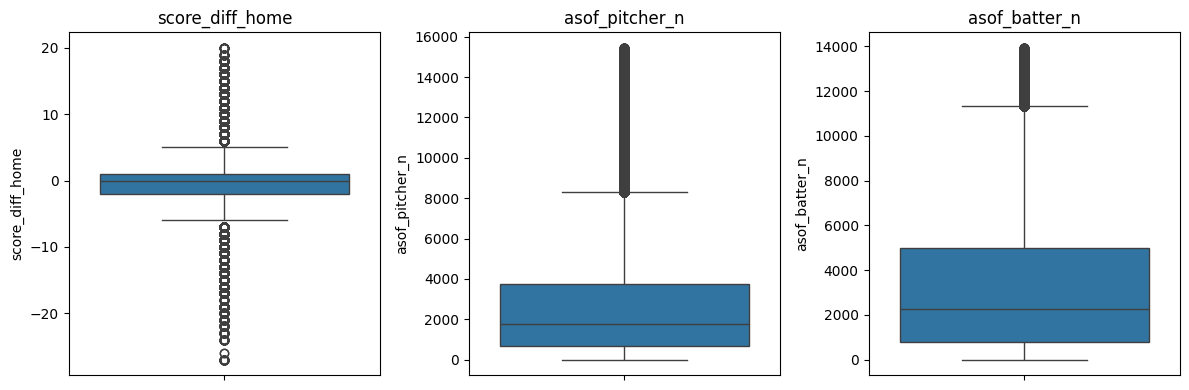

In [7]:
# [5] 통계적 극단값 탐색 (IQR & ESD)

print("[5] Statistical Outliers (IQR & Z-score)")
# 극단값을 확인할 주요 연속형 변수들
check_cols = ['score_diff_home', 'asof_pitcher_n', 'asof_batter_n']
for col in check_cols:
    # 1. IQR (4분위수) 방식 계산
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_iqr = train[(train[col] < lower_bound) | (train[col] > upper_bound)]

    # 2. ESD (Z-score, 3표준편차) 방식 계산
    mean_val = train[col].mean()
    std_val = train[col].std()
    outliers_z = train[(train[col] < mean_val - 3*std_val) | (train[col] > mean_val + 3*std_val)]

    print(f"\n▶ [{col}]")
    print(f"- IQR 기준 (Lower: {lower_bound:.1f}, Upper: {upper_bound:.1f})")
    print(f"  └ 극단값 개수: {len(outliers_iqr):,}개 ({len(outliers_iqr)/len(train)*100:.2f}%)")
    print(f"- ESD 기준 (Mean ± 3*Std)")
    print(f"  └ 극단값 개수: {len(outliers_z):,}개 ({len(outliers_z)/len(train)*100:.2f}%)")

# 시각화로 확인하기 (Boxplot)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 4))
for i, col in enumerate(check_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=train[col])
    plt.title(col)
plt.tight_layout()
plt.show()

### [5] 통계적 극단값 탐색 (IQR & ESD)
주요 연속형 변수에 대해 통계적 극단값(IQR 및 3-Sigma 기준)의 분포를 검증함.
IQR 기준으로 홈팀 점수 차이(`score_diff_home`)는 약 9.38%, 투수 누적 투구수(`asof_pitcher_n`)는 약 5.52%가 상하한선을 이탈함.
해당 극단값들은 수집 오류가 아니며, 점수 차이가 크게 벌어진 가비지 타임이나 베테랑 선수의 다출장 등 야구 경기의 실제 특수 상황을 반영하는 정상 지표임. 따라서 해당 데이터들을 통상적인 이상치로 간주하여 제거하지 않음.

#**데이터 전처리**


### [6] 데이터 전처리 (Preprocessing)

머신러닝(트리 모델)이 데이터를 정상적으로 학습할 수 있도록 최소한의 필수 전처리를 수행함.

**1. 범주형 변수 수치화 (Label Encoding)**
- 모델이 계산할 수 없는 문자열(String) 형태의 범주형 데이터를 숫자로 치환함.
- 대상 변수: `top_bottom`(초/말), `pitcher_hand`(투수 좌우), `batter_hand`(타자 좌우), `game_type`(경기 타입), `base_state`(주자 상황)
- 각 문자열 고유값을 0, 1, 2 등의 정수로 맵핑(Mapping)하여 처리 완료.

**2. 불필요한 식별자(ID) 제거 (Drop)**
- 제구력 예측에 어떠한 패턴도 제공하지 않고 과적합(Overfitting)만 유발할 수 있는 단순 고유 식별 번호를 학습 데이터에서 제외함.
- 제거 대상: `row_id`, `batter_id`
- *※ 예외 처리*: `pitcher_id`의 경우, 이후 트랙맨(Trackman) 과거 로그 데이터를 병합(Merge)할 때 연결고리(Key)로 사용해야 하므로 현 단계에서는 삭제하지 않고 보존함.

In [8]:
# 1. 문자열 변수를 숫자로 치환 (Label Encoding)
from sklearn.preprocessing import LabelEncoder

# 문자로 되어 있는 범주형 컬럼들 목록
categorical_cols = ['top_bottom', 'pitcher_hand', 'batter_hand', 'game_type', 'base_state']

# 사이킷런의 LabelEncoder를 사용해 각각의 컬럼을 숫자로 변환
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    # NaN(결측치)가 혹시 문자에 섞여있을 경우를 대비해 문자열(str)로 통일한 뒤 인코딩
    train[col] = le.fit_transform(train[col].astype(str))
    label_encoders[col] = le


display(train[categorical_cols].head())

,top_bottom,pitcher_hand,batter_hand,game_type,base_state
0,1,0,1,1,7
1,1,0,0,1,3
2,1,0,0,1,3
3,1,0,0,1,7
4,1,0,0,1,7


In [9]:
# 2. 쓸모없는 ID 컬럼 버리기 (Drop)

# 버릴 컬럼들 지정 (pitcher_id는 나중에 트랙맨 데이터를 붙이기 위해 잠시 살려둡니다)
drop_cols = ['row_id', 'batter_id']

# 데이터프레임에서 해당 컬럼들 삭제 (axis=1은 컬럼을 의미, inplace=True는 원본에 바로 적용)
train.drop(drop_cols, axis=1, inplace=True)

print(f"현재 남은 컬럼 개수: {train.shape[1]}개")

현재 남은 컬럼 개수: 47개


#**데이터 변수 생성**

*   학습에 활용될 때 필요한 데이터 변수들을 어떻게 생성하고 활용할지 구상.
*   1. 그대로 사용하는 방법. + 2. 파생변수를 생성하여 선수의 지표로 활용.

### [7] 데이터 변수 활용 전략 (Feature Selection)

EDA 결과를 바탕으로 변수들을 있는 그대로 활용할 것(AS-IS)과 가공할 것(TO-BE)으로 분류함.

**1. 원본 그대로 사용할 주요 변수 (AS-IS)**
* **상황 압박감 지표 (`li`)**: 레버리지 인덱스(상황 중요도). 투수가 느끼는 경기 흐름상 압박감을 가장 직접적으로 대변하므로 변환 없이 그대로 사용함.
* **이닝 (`inning`)**: 경기 초/후반을 나누는 지표로서 선수의 체력 및 집중력 저하 패턴을 모델이 학습할 수 있도록 원본 유지.
* **좌우 매치업 (`pitcher_hand`, `batter_hand`)**: 야구 도메인에서 매우 중요한 투타 상성을 나타내는 범주형(Categorical) 변수로, 별도의 수학적 가공 없이 인코딩하여 활용함.
* **과거 누적 비율 (`asof_..._rate`)**: 투수/타자의 과거 제구 성공률, 직구 비율 등은 이미 0~1 사이로 깔끔하게 정규화(Scaling)되어 있으므로 그대로 투입함. (신인 선수의 결측치는 트리 모델 자체 분기 기능에 위임)

*※ 이후 과정에서는 기존의 개별 변수들(볼, 스트라이크, 주자, 점수 차 등)을 논리적으로 조합하여, 투수의 심리적/물리적 압박감을 더 직접적으로 나타내는 파생 변수(Feature Engineering) 생성을 진행할 예정임.*

**2. 파생 변수(Feature Engineering) 생성 기획안 (TO-BE)**
기존의 개별 상황 변수들을 조합하여 투수의 심리적, 물리적 압박감을 모델이 직관적으로 학습할 수 있도록 파생 변수를 생성함.

* **볼카운트 기반 압박감 (`is_pitcher_behind`, `is_full_count`)**:
  - `balls_before`와 `strikes_before` 데이터를 조합함. 투수가 카운트 싸움에서 불리할 때(예: 볼 > 스트라이크) 볼넷을 피하기 위해 존 안으로 던지려다 제구에 실패하는 현상을 포착하기 위한 이진 변수(0 또는 1)를 생성함.
* **득점권 및 클러치 상황 (`is_scoring_position`, `is_clutch`, `is_garbage_time`)**:
  - `runner_on_2b`, `runner_on_3b` 및 점수 차이(`score_diff_pitcher_team`) 데이터를 조합함.
  - 2, 3루 득점권 위기이거나 경기 후반(7회 이후) 1점 차 이내의 박빙 상황일 때 투수의 심리적 부담감을 모델에 전달함. 반대로 7점 이상 차이가 나는 가비지 타임에서의 긴장감 저하 현상도 함께 수치화함.
* **투타 경험치 격차 (`experience_diff`)**:
  - 투수 누적 투구수(`asof_pitcher_n`)와 타자 누적 투구수(`asof_batter_n`)의 차이를 계산함. 노련한 베테랑 타자를 상대하는 신인 투수의 부담감 혹은 그 반대의 상황을 정량적으로 평가함.
* **트랙맨 프로필 요약 (`pitcher_avg_velocity`, `pitcher_avg_spin_rate` 등)**:
  - 별도 제공된 `trackman_history.csv` 데이터를 활용하여, 투수 ID(`pitcher_id`) 기준으로 그룹화(Aggregation) 및 평균값을 산출함.
  - 해당 투수의 고유한 구위 능력치(과거 평균 구속, 평균 회전수, 릴리스 포인트 등)를 추출한 후 메인 학습 데이터에 병합(Merge)하여 강력한 피처로 활용함.

In [10]:
# 파생 변수(Feature Engineering) 생성
import numpy as np

# (1) 볼카운트 압박감 지표
# 볼이 스트라이크보다 많아서 투수가 불리한 카운트 (볼넷 압박감)
train['is_pitcher_behind'] = (train['balls_before'] > train['strikes_before']).astype(int)

# 풀카운트 (3볼 2스트라이크 승부처)
train['is_full_count'] = ((train['balls_before'] == 3) & (train['strikes_before'] == 2)).astype(int)

# (2) 경기 후반 압박감 지표 (클러치 & 가비지)
# 7회 이후이면서 점수 차이가 1점 이하인 팽팽한 쫄깃한 승부처
train['is_clutch'] = ((train['inning'] >= 7) & (train['score_diff_home'].abs() <= 1)).astype(int)

# 점수 차이가 7점 이상 크게 벌어져 긴장감이 떨어지는 가비지 타임
train['is_garbage_time'] = (train['score_diff_home'].abs() >= 7).astype(int)

# (3) 투타 경험치 격차 (짬바 차이)
# 투수의 누적 투구수에서 타자의 누적 투구수를 빼서, 투수가 상대적으로 얼마나 노련한지 계산
train['experience_diff'] = train['asof_pitcher_n'] - train['asof_batter_n']

# 새로 만든 변수들만 앞부분 5줄 확인
new_cols = ['is_pitcher_behind', 'is_full_count', 'is_clutch', 'is_garbage_time', 'experience_diff']
display(train[new_cols].head())

,is_pitcher_behind,is_full_count,is_clutch,is_garbage_time,experience_diff
0,0,0,0,0,0
1,0,0,0,0,1
2,1,0,0,0,1
3,0,0,0,0,3
4,0,0,0,0,3


In [11]:
# 피처(변수) 리스트 분리 보관

# 1. 원본 그대로 사용할 변수 리스트
base_features = [
    'li',            # 상황 압박감 지수
    'inning',        # 이닝 (체력 저하 지표)
    'pitcher_hand',  # 투수 좌우
    'batter_hand'    # 타자 좌우
]

# 'asof_'로 시작하는 과거 누적 기록 변수들을 모두 찾아서 base_features에 추가
asof_cols = [col for col in train.columns if 'asof_' in col]
base_features.extend(asof_cols)

# 2. 파생 변수 리스트
derived_features = [
    'is_pitcher_behind', # 카운트 불리 여부
    'is_full_count',     # 풀카운트 여부
    'is_clutch',         # 팽팽한 승부처 여부
    'is_garbage_time',   # 가비지 타임 여부
    'experience_diff'    # 투타 경험치 격차
]

# 최종 모델 학습용 변수 (전체) -> 나중에 모델을 학습시킬 때는 이 final_features만 쏙 집어넣을 예정!
final_features = base_features + derived_features

print(f"✅ 원본 변수(AS-IS) 개수: {len(base_features)}개")
print(f"✅ 파생 변수(TO-BE) 개수: {len(derived_features)}개")
print(f"✅ 총 학습용 피처 개수: {len(final_features)}개")

# 리스트 확인해보기
print("\n[파생 변수 리스트 확인]")
print(derived_features)

✅ 원본 변수(AS-IS) 개수: 23개
✅ 파생 변수(TO-BE) 개수: 5개
✅ 총 학습용 피처 개수: 28개

[파생 변수 리스트 확인]
['is_pitcher_behind', 'is_full_count', 'is_clutch', 'is_garbage_time', 'experience_diff']


### [8] 외부 데이터 병합: 트랙맨 투수 프로필 (Trackman)
과거 트랙맨 로그 데이터를 집계하여 투수별 고유의 물리적 구위 능력치(평균 구속, 회전수 등)를 파생 변수로 추가함. 병합을 완료한 후에는 식별자인 `pitcher_id`를 마저 제거함.

In [12]:
# ==========================================
# 5. 트랙맨(Trackman) 데이터 병합 (투수 프로필)
# ==========================================
import pandas as pd
import numpy as np

# 1. 트랙맨 데이터 불러오기 (용량이 크므로 시간 약간 소요)
trackman_path = '/content/trackman_history.csv' # 코랩 내 트랙맨 파일 경로 (본인 환경에 맞게 수정)
trackman = pd.read_csv(trackman_path)

# 2. 투수별 핵심 구위(물리) 데이터 요약(평균) 추출
# 우리가 관심을 가질 구속, 회전수, 무브먼트, 익스텐션, 릴리스 포인트 변수들
trackman_cols = ['rel_speed', 'spin_rate', 'induced_vert_break', 'horz_break', 'extension', 'rel_height', 'rel_side']

# 투수 ID 기준으로 그룹화(groupby)하여 평균(mean) 계산
pitcher_profile = trackman.groupby('pitcher_trackman_id')[trackman_cols].mean().reset_index()

# 컬럼 이름을 'avg_rel_speed' 처럼 알기 쉽게 변경하고, Key 역할을 할 ID 이름도 'pitcher_id'로 통일
pitcher_profile.columns = ['pitcher_id'] + [f'avg_{col}' for col in trackman_cols]

# 3. 메인 데이터(train)에 트랙맨 프로필 병합 (Left Join)
train = pd.merge(train, pitcher_profile, on='pitcher_id', how='left')

# 병합 완료 후 쓸모가 다한 pitcher_id는 최종 삭제 (Drop)
train.drop(['pitcher_id'], axis=1, inplace=True, errors='ignore')

# 방금 추가된 트랙맨 변수들을 파생 변수 리스트에 업데이트
new_trackman_features = [f'avg_{col}' for col in trackman_cols]
derived_features.extend(new_trackman_features)

# 최종 학습용 피처 리스트 완성
final_features = base_features + derived_features

print("✅ 트랙맨 데이터 투수 프로필 병합 및 ID 삭제 완료!")
print(f"새로 추가된 구위 피처들: {new_trackman_features}")
print(f"🌟 최종 학습용 피처 개수: {len(final_features)}개")

# 데이터 잘 붙었는지 확인
display(train[new_trackman_features].head())

✅ 트랙맨 데이터 투수 프로필 병합 및 ID 삭제 완료!
새로 추가된 구위 피처들: ['avg_rel_speed', 'avg_spin_rate', 'avg_induced_vert_break', 'avg_horz_break', 'avg_extension', 'avg_rel_height', 'avg_rel_side']
🌟 최종 학습용 피처 개수: 35개


,avg_rel_speed,avg_spin_rate,avg_induced_vert_break,avg_horz_break,avg_extension,avg_rel_height,avg_rel_side
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### [9] 머신러닝 학습 및 평가 (LightGBM)
정제된 최종 데이터(`final_features`)를 활용하여 데이터를 분할(Train/Validation)하고, 트리 기반 앙상블 알고리즘인 LightGBM 모델을 학습시킨 뒤 피처 중요도를 확인합니다.

✅ 데이터 분할 완료!
학습용 데이터 크기(Train): (1180073, 35)
모의고사용 데이터 크기(Valid): (295019, 35)

⏳ 모델 학습을 시작합니다. (데이터가 많아 수 분 정도 소요될 수 있습니다...)
Training until validation scores don't improve for 50 rounds
[100]	Train's binary_logloss: 0.684109	Valid's binary_logloss: 0.685188
[200]	Train's binary_logloss: 0.682602	Valid's binary_logloss: 0.684765
[300]	Train's binary_logloss: 0.681309	Valid's binary_logloss: 0.684471
[400]	Train's binary_logloss: 0.680111	Valid's binary_logloss: 0.68429
[500]	Train's binary_logloss: 0.678929	Valid's binary_logloss: 0.684065
[600]	Train's binary_logloss: 0.677821	Valid's binary_logloss: 0.683929
[700]	Train's binary_logloss: 0.676774	Valid's binary_logloss: 0.683809
[800]	Train's binary_logloss: 0.675753	Valid's binary_logloss: 0.683747
[900]	Train's binary_logloss: 0.67475	Valid's binary_logloss: 0.683657
[1000]	Train's binary_logloss: 0.673742	Valid's binary_logloss: 0.683575
[1100]	Train's binary_logloss: 0.672766	Valid's binary_logloss: 0.68351
[1200]	Train's binar

<Figure size 1000x800 with 0 Axes>

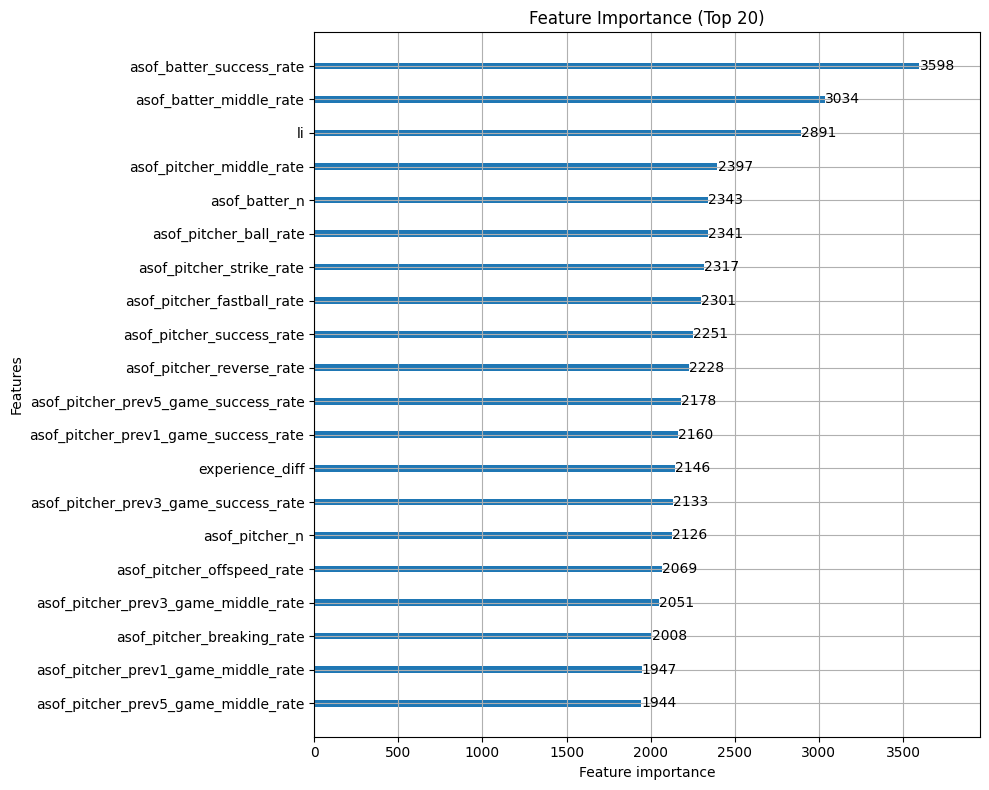

In [13]:
# 데이터 분할 (Train / Validation)
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

# 앞서 모아둔 학습용 피처(final_features)와 정답지(Target) 설정
X = train[final_features]
y = train['control_success']

# 전체 데이터를 80%의 학습용(train)과 20%의 모의고사용(valid)으로 무작위 분할
# stratify=y를 통해 두 세트 모두 성공/실패 비율이 5:5로 일정하게 유지되도록 설정
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ 데이터 분할 완료!")
print(f"학습용 데이터 크기(Train): {X_train.shape}")
print(f"모의고사용 데이터 크기(Valid): {X_valid.shape}")

# 7. LightGBM 모델 학습
# LightGBM 전용 데이터 포맷으로 변환
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_valid = lgb.Dataset(X_valid, label=y_valid, reference=lgb_train)

# 하이퍼파라미터(설정값) 세팅
params = {
    'objective': 'binary',        # 이진 분류 (성공 1, 실패 0 예측)
    'metric': 'binary_logloss',   # 평가 지표: Logloss (대회 목표인 '확률' 예측에 가장 적합)
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,        # 학습 속도
    'num_leaves': 31,             # 트리의 복잡도 (너무 크면 과적합 발생)
    'verbose': -1                 # 불필요한 시스템 로그 숨김
}

print("\n⏳ 모델 학습을 시작합니다. (데이터가 많아 수 분 정도 소요될 수 있습니다...)")

# 모델 학습 진행
# num_boost_round=1000 : 최대 1000번 반복 학습
# early_stopping(50) : 50번 반복하는 동안 모의고사(Valid) 성적이 안 오르면 미련 없이 학습 조기 종료!
model = lgb.train(
    params,
    lgb_train,
    valid_sets=[lgb_train, lgb_valid],
    valid_names=['Train', 'Valid'],
    num_boost_round=1622,
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

print("\n🎉 모델 학습 완료!")

# 피처 중요도 (Feature Importance) 시각화
# AI가 제구 성공 여부를 맞출 때 어떤 변수(힌트)를 가장 중요하게 썼는지 랭킹을 매겨봅니다.
plt.figure(figsize=(10, 8))
# split 기준: 해당 변수가 의사결정 나무에서 질문(분기)으로 몇 번이나 사용되었는가
lgb.plot_importance(model, max_num_features=20, importance_type='split', title='Feature Importance (Top 20)', figsize=(10, 8))
plt.tight_layout()
plt.show()

### [10] 평가 데이터(Test) 예측 및 제출 파일 생성
학습된 모델을 활용하여 실제 평가 데이터의 제구 성공 확률을 예측하고, 리더보드에 제출할 최종 CSV 파일을 생성합니다. (Train과 완벽하게 동일한 전처리 과정을 거쳐야 함에 유의)

In [14]:
# Test 데이터 전처리 및 예측 (최종 제출 파일 생성)
import pandas as pd
import numpy as np

# 평가용 파일 불러오기
test_path = '/content/test.csv'
submission_path = '/content/sample_submission.csv'
test = pd.read_csv(test_path)
submission = pd.read_csv(submission_path)

# Test 데이터 전처리 (Label Encoding)
# 핵심: Train 데이터를 변환할 때 썼던 '그 인코더(label_encoders)'를 그대로 써야 숫자가 꼬이지 않습니다!
for col in categorical_cols:
    le = label_encoders[col]
    # 만약 Test 데이터에 Train에서 본 적 없는 새로운 글자가 나오면 에러가 나므로, 안전 장치 추가
    test[col] = test[col].astype(str).apply(lambda x: x if x in le.classes_ else le.classes_[0])
    test[col] = le.transform(test[col])

# Test 데이터 파생 변수(TO-BE) 똑같이 생성
test['is_pitcher_behind'] = (test['balls_before'] > test['strikes_before']).astype(int)
test['is_full_count'] = ((test['balls_before'] == 3) & (test['strikes_before'] == 2)).astype(int)
test['is_clutch'] = ((test['inning'] >= 7) & (test['score_diff_home'].abs() <= 1)).astype(int)
test['is_garbage_time'] = (test['score_diff_home'].abs() >= 7).astype(int)
test['experience_diff'] = test['asof_pitcher_n'] - test['asof_batter_n']

# 외부 데이터(트랙맨 프로필) 병합
# 아까 Train 때 요약해둔 'pitcher_profile'을 Test 투수들에게도 그대로 달아줍니다.
test = pd.merge(test, pitcher_profile, on='pitcher_id', how='left')

# 최종 제구 성공 확률 예측
# 모델이 학습할 때 보았던 변수 순서(final_features)를 그대로 지켜서 넣어주어야 합니다.
X_test = test[final_features]

# predict() 함수는 0.0 ~ 1.0 사이의 '제구 성공 확률'을 계산해 줍니다.
test_preds = model.predict(X_test)

# 제출 파일(Submission) 만들기
submission['control_success'] = test_preds

# 코랩 환경에 'final_submission.csv'라는 이름으로 최종 저장!
submission.to_csv('/content/final_submission.csv', index=False)

print("✅ Test 예측 및 제출용 파일(final_submission.csv) 생성 완료!")
display(submission.head())

✅ Test 예측 및 제출용 파일(final_submission.csv) 생성 완료!


,row_id,control_success
0,TEST_000001,0.442852
1,TEST_000017,0.408593
2,TEST_000213,0.505926
3,TEST_005332,0.538148
4,TEST_035185,0.541049
